In [ ]:
!pip install numpy pandas matplotlib yfinance
#下载yfinance 数据源

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

#说明：WEEK 1
#数据获取 处理 计算 可视化 基本练习

# 1. 下载数据
#ticker = "AAPL"
#data = yf.download(ticker, start="2020-01-01", end="2023-12-31")
#data.head()
# 2. 检查缺失值
#data.isnull().sum()   yfinance 出现问题，请求过多

## 由于 Yahoo Finance 请求频率限制，我们使用 NumPy 生成模拟价格数据来完成练习。

# 1.生成日期范围（2020-01-01 到 2023-12-31）
dates = pd.date_range(start="2020-01-01", end="2023-12-31")
n = len(dates)

# 2.生成每日对数收益率（假设服从正态分布，均值 0.05%/天，标准差 2%/天）
log_returns = np.random.normal(loc=0.0005, scale=0.02, size=n)

#收益率与对数收益率：对数不直观，但是具有可加性，数据处理更方便，R=P1-P0/P0,LogR=ln(P1/P0)

# 从起始价格 100 开始累乘得到价格序列
price = 100 * np.exp(np.cumsum(log_returns))

#3.创建 DataFrame
data = pd.DataFrame({'Close': price}, index=dates)
print("生成的数据：")
data.loc['2022-01-10':'2022-02-10']
#data.head()默认前5行，括号里直接输入想要的数据数量

#检查数据缺失
#data.isnull().sum()  用于查找缺失值，会输出0,1,2...

#4. 计算每日收益率
data['Return'] = data['Close'].pct_change()  # 简单收益率
data['Log_Return'] = log_returns  # 我们直接使用生成时用的对数收益率（可选）

print("添加收益率后的数据：")
data.loc['2022-01-10':'2022-02-10']

## 5. 计算滚动波动率（20日年化波动率）
# 波动率 = 收益率的标准差 * sqrt(252)
data['Volatility'] = data['Return'].rolling(window=20).std() * np.sqrt(252)#这行只是赋值，没有输出功能

#20日均价，前20日平均，连成20日均线看趋势，看多空方向，与实际对比
data['SMA_20'] = data['Close'].rolling(window=20).mean()

data.loc['2022-01-10':'2022-02-10'] #head tail loc 不同切片方式



生成的数据：
添加收益率后的数据：


,Close,Return,Log_Return,Volatility,SMA_20
2022-01-10,137.067636,-0.041221,-0.042095,0.251265,139.194827
2022-01-11,136.093503,-0.007107,-0.007132,0.252318,139.058127
2022-01-12,144.612603,0.062597,0.060716,0.326970,139.495059
2022-01-13,146.448196,0.012693,0.012613,0.327972,140.036961
2022-01-14,144.418422,-0.013860,-0.013957,0.333154,140.410198
2022-01-15,141.789860,-0.018201,-0.018369,0.340172,140.584835
2022-01-16,142.802047,0.007139,0.007113,0.337200,140.706940
2022-01-17,144.294386,0.010450,0.010396,0.329134,141.044425
2022-01-18,146.223597,0.013370,0.013281,0.324129,141.330154
2022-01-19,144.970880,-0.008567,-0.008604,0.326330,141.551839


In [16]:

# 或者更具体地查看 Close 和 SMA_20 列
data[['Close', 'SMA_20']].tail(10)  # 查看最后10行，更容易看到有效值


,Close,SMA_20
2023-12-22,588.170179,579.911820
2023-12-23,591.279304,579.943632
2023-12-24,582.391482,580.025236
2023-12-25,574.594485,580.211092
2023-12-26,587.376923,581.425809
2023-12-27,595.009051,583.120786
2023-12-28,604.306267,585.301857
2023-12-29,586.707378,587.251483
2023-12-30,591.806659,588.983229
2023-12-31,599.470312,590.203448


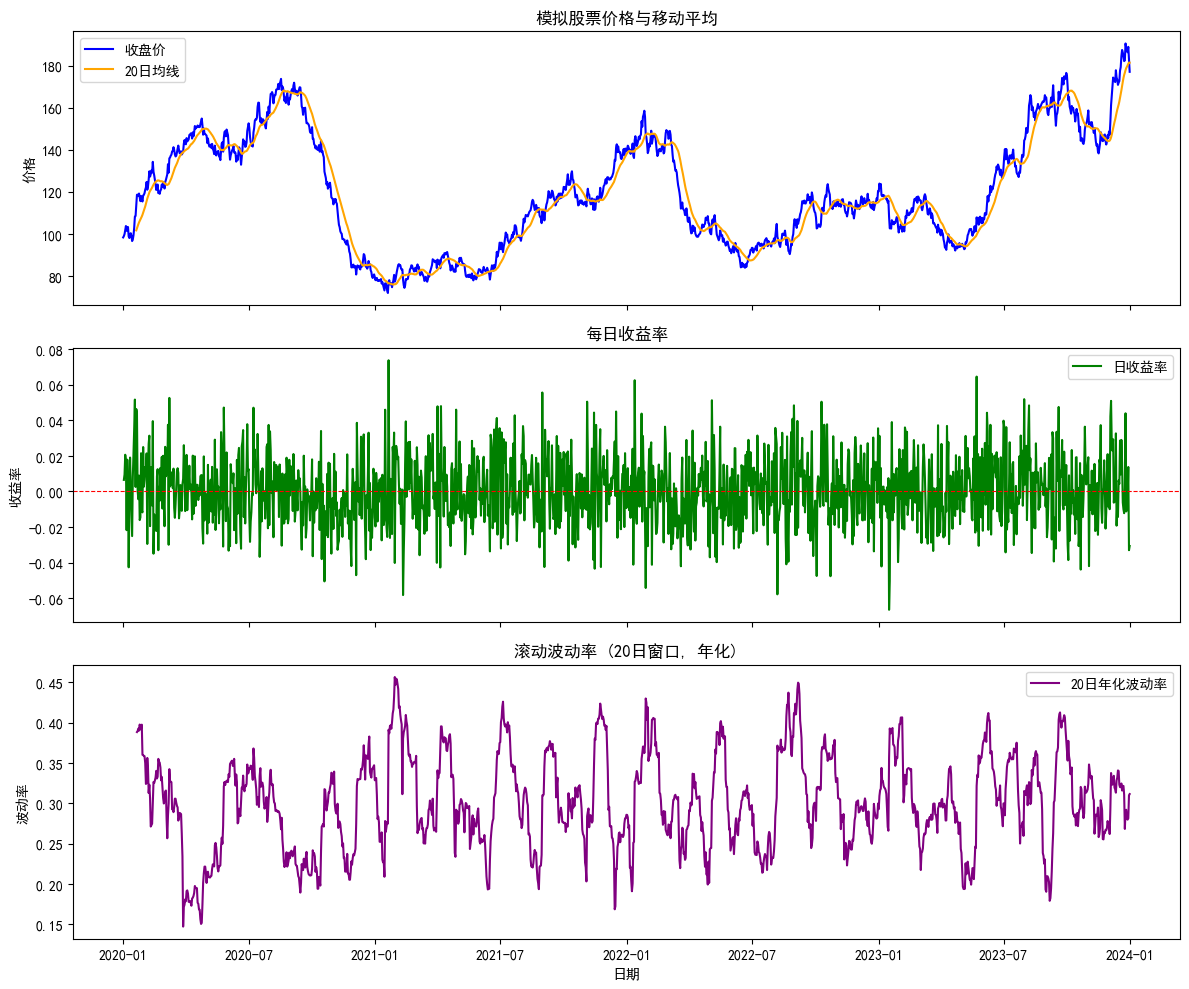

In [25]:


# 6. 绘制三个子图：价格+均线、收益率、波动率
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 第一子图：收盘价和20日均线
axes[0].plot(data.index, data['Close'], label='收盘价', color='blue')
axes[0].plot(data.index, data['SMA_20'], label='20日均线', color='orange')
axes[0].set_ylabel('价格')
axes[0].legend()
axes[0].set_title('模拟股票价格与移动平均')

# 第二子图：每日收益率
axes[1].plot(data.index, data['Return'], label='日收益率', color='green')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('收益率')
axes[1].legend()
axes[1].set_title('每日收益率')

# 第三子图：滚动波动率
axes[2].plot(data.index, data['Volatility'], label='20日年化波动率', color='purple')
axes[2].set_ylabel('波动率')
axes[2].set_xlabel('日期')
axes[2].legend()
axes[2].set_title('滚动波动率 (20日窗口, 年化)')

plt.tight_layout()
plt.show()


In [27]:
# ## 7. 额外练习：使用 groupby 按年份统计

#groupby智能分组聚合，尤其擅长按照时间分组
data['Year'] = data.index.year
yearly_mean_return = data.groupby('Year')['Return'].mean()
print("各年平均日收益率：")
print(yearly_mean_return)

各年平均日收益率：
Year
2020   -0.000411
2021    0.001726
2022   -0.000204
2023    0.001255
Name: Return, dtype: float64


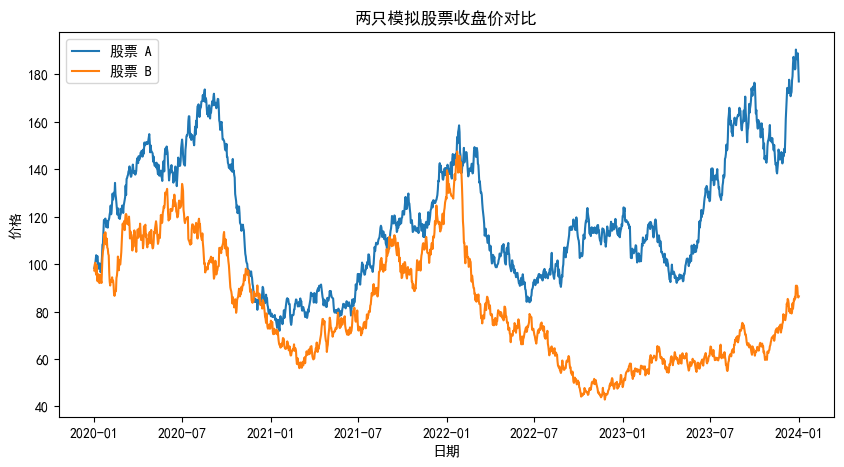

In [26]:
# ## 8. 额外练习：merge 两个模拟股票数据
# merge用于合并数据，pandas数据分析库里的核心工具之一
# 生成第二个股票的价格序列，然后与第一个合并，以便比较。

# %%
# 生成第二个股票（比如股票 B）的价格数据，使用不同的随机种子
np.random.seed(123)
log_returns_b = np.random.normal(loc=0.0003, scale=0.025, size=n)
price_b = 100 * np.exp(np.cumsum(log_returns_b))
data_b = pd.DataFrame({'Close_B': price_b}, index=dates)

# 合并两个 DataFrame
combined = pd.merge(data[['Close']], data_b, left_index=True, right_index=True)
combined.head()

# 绘制两个收盘价的对比图
plt.figure(figsize=(10, 5))
plt.plot(combined.index, combined['Close'], label='股票 A')
plt.plot(combined.index, combined['Close_B'], label='股票 B')
plt.ylabel('价格')
plt.xlabel('日期')
plt.title('两只模拟股票收盘价对比')
plt.legend()
plt.show()

# %% [markdown]
# ## 完成